<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_xor_interference_gate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D6_XOR_INTERFERENCE — Diffusion XOR Interference Gate

Status

Working prototype target.

Purpose

This notebook demonstrates a diffusion-based XOR interference gate.

The gate produces a stable output when exactly one input is active.

When both inputs are active, their overlap creates destructive interference and suppresses the output.

Expected Result

A| B| State| Output
0| 0| EMPTY| 0
1| 0| STABLE| 1
0| 1| STABLE| 1
1| 1| INTERFERENCE| 0

Interpretation

A single input creates a stable field.

Two simultaneous inputs create an interference zone.

The interference zone destroys or suppresses the output.

This means the system behaves as a diffusion-based XOR gate:

exactly one active input → stable output

both inputs active → destructive interference

Diffusion Alphabet Mapping

Symbol:

D6_XOR_INTERFERENCE

Family:

Logic / Interference / Conflict

Meaning:

A two-field system where exactly one active input produces stable output, while two active inputs suppress the output through destructive field interference.

Repository Name

Recommended notebook filename:

notebooks/diffusion_xor_interference_gate.ipynb

Experiment Label

Experiment 04 — Diffusion XOR Interference

Commit Message

Add diffusion XOR interference gate prototype

A: 0 B: 0
STATE: EMPTY


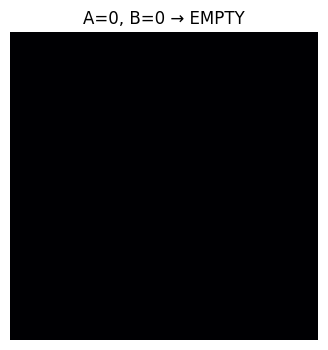

A: 1 B: 0
STATE: STABLE


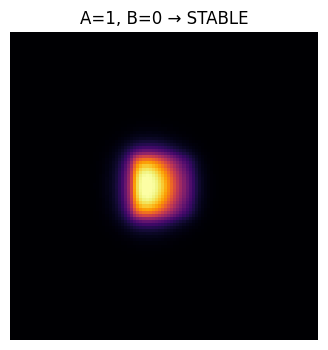

A: 0 B: 1
STATE: STABLE


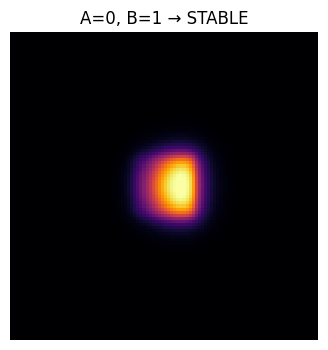

A: 1 B: 1
STATE: INTERFERENCE


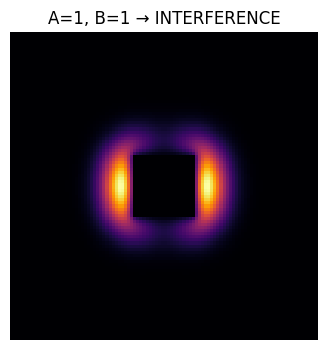

,A,B,state,output,mass,center,max
0,0,0,EMPTY,0,0.000,0.000,0.000
1,1,0,STABLE,1,323.251,241.144,1.000
2,0,1,STABLE,1,323.251,241.144,1.000
3,1,1,INTERFERENCE,0,16.015,0.000,0.034


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def laplacian(Z):
    return (
        -4 * Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    )


def make_xor_fields(a=0, b=0, size=100):
    X = np.zeros((size, size), dtype=float)
    Y = np.zeros((size, size), dtype=float)

    if a == 1:
        X[45:55, 35:45] = 1.0

    if b == 1:
        Y[45:55, 55:65] = 1.0

    return X, Y


def diffuse_xor_interference_gate(
    X,
    Y,
    steps=220,
    diffusion=0.20,
    field_decay=0.006,
    output_diffusion=0.12,
    growth=0.45,
    output_decay=0.015,
    conflict_penalty=2.2,
    burn=0.8
):
    X = X.copy()
    Y = Y.copy()
    Z = np.zeros_like(X)

    for _ in range(steps):
        X = X + diffusion * laplacian(X) - field_decay * X
        Y = Y + diffusion * laplacian(Y) - field_decay * Y

        X = np.clip(X, 0, 1)
        Y = np.clip(Y, 0, 1)

        conflict = np.sqrt(X * Y)

        xor_drive = np.clip((X + Y) - conflict_penalty * conflict, 0, 1)

        gate_drive = np.zeros_like(Z)
        gate_conflict = np.zeros_like(Z)

        gate_drive[40:60, 40:60] = xor_drive[40:60, 40:60]
        gate_conflict[40:60, 40:60] = conflict[40:60, 40:60]

        Z = (
            Z
            + output_diffusion * laplacian(Z)
            + growth * gate_drive
            - output_decay * Z
            - burn * gate_conflict
        )

        Z = np.clip(Z, 0, 1)

    return X, Y, Z


def detect_xor_state(Z, a, b):
    total_mass = float(Z.sum())
    center_mass = float(Z[40:60, 40:60].sum())
    max_value = float(Z.max())

    if a == 0 and b == 0 and total_mass < 1.0:
        return "EMPTY"

    if a == 1 and b == 1:
        if center_mass < 5.0 and max_value < 0.10:
            return "INTERFERENCE"
        return "INTERFERENCE"

    if center_mass > 20.0 and max_value > 0.05:
        return "STABLE"

    return "DECAY"


cases = [(0, 0), (1, 0), (0, 1), (1, 1)]
results = []

for a, b in cases:
    X0, Y0 = make_xor_fields(a, b)
    X, Y, Z = diffuse_xor_interference_gate(X0, Y0)
    state = detect_xor_state(Z, a, b)

    results.append({
        "A": a,
        "B": b,
        "state": state,
        "output": 1 if state == "STABLE" else 0,
        "mass": round(float(Z.sum()), 3),
        "center": round(float(Z[40:60, 40:60].sum()), 3),
        "max": round(float(Z.max()), 3),
    })

    print("====================")
    print("A:", a, "B:", b)
    print("STATE:", state)

    plt.figure(figsize=(4, 4))
    plt.imshow(Z, cmap="inferno")
    plt.title(f"A={a}, B={b} → {state}")
    plt.axis("off")
    plt.show()

df = pd.DataFrame(results)
df